# Detecção de Objetos com YOLOS Small

Este notebook demonstra como usar o modelo `hustvl/yolos-small` da Hugging Face para realizar detecção de objetos nas imagens da pasta `images/`.

O YOLOS (You Only Look at One Sequence) trata a detecção de objetos como uma tarefa de sequência para sequência usando um Transformer puro.

In [1]:
import torch
from transformers import YolosImageProcessor, YolosForObjectDetection
from PIL import Image, ImageDraw, ImageFont
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display

# 1. Configurações Iniciais
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "hustvl/yolos-small"

print(f"Carregando processador e modelo: {model_name}...")
image_processor = YolosImageProcessor.from_pretrained(model_name)
model = YolosForObjectDetection.from_pretrained(model_name).to(device)
model.eval()

print(f"Modelo carregado no dispositivo: {device}")

c:\projetonlw\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Carregando processador e modelo: hustvl/yolos-small...


c:\projetonlw\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\luisf\.cache\huggingface\hub\models--hustvl--yolos-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 212/212 [00:00<00:00, 4878.97it/s]

Modelo carregado no dispositivo: cpu


## 2. Função de Detecção e Visualização
Esta função processa a imagem, executa a detecção e desenha as caixas delimitadoras (bounding boxes).

In [2]:
def detect_objects(image_path, threshold=0.9):
    image = Image.open(image_path).convert("RGB")
    
    # Preparar a imagem para o modelo
    inputs = image_processor(images=image, return_tensors="pt").to(device)
    
    # Executar a detecção
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Converter as predições do modelo para coordenadas de caixa e classes amigáveis
    # O processador converte as saídas para as dimensões originais da imagem
    target_sizes = torch.tensor([image.size[::-1]])
    results = image_processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=threshold)[0]

    # Configurar plot
    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(image)
    
    colors = plt.cm.hsv(torch.linspace(0, 1, 80)).tolist() # COCO has 80 classes

    found_objects = False
    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        found_objects = True
        box = [round(i, 2) for i in box.tolist()]
        x, y, x2, y2 = box
        width, height = x2 - x, y2 - y
        
        # Criar a caixa delimitadora
        color = colors[label.item() % len(colors)]
        rect = patches.Rectangle((x, y), width, height, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        
        # Adicionar o label com a confiança
        label_name = model.config.id2label[label.item()]
        ax.text(x, y, f"{label_name}: {score:.2f}", bbox=dict(facecolor=color, alpha=0.5), color='white', fontweight='bold')

    plt.axis('off')
    plt.title(f"Deteccão em: {os.path.basename(image_path)}")
    plt.show()
    
    if not found_objects:
        print(f"Nenhum objeto detectado com confiança acima de {threshold*100}%")

## 3. Executar Detecção na pasta 'images/'


Processando: bird.jpg...


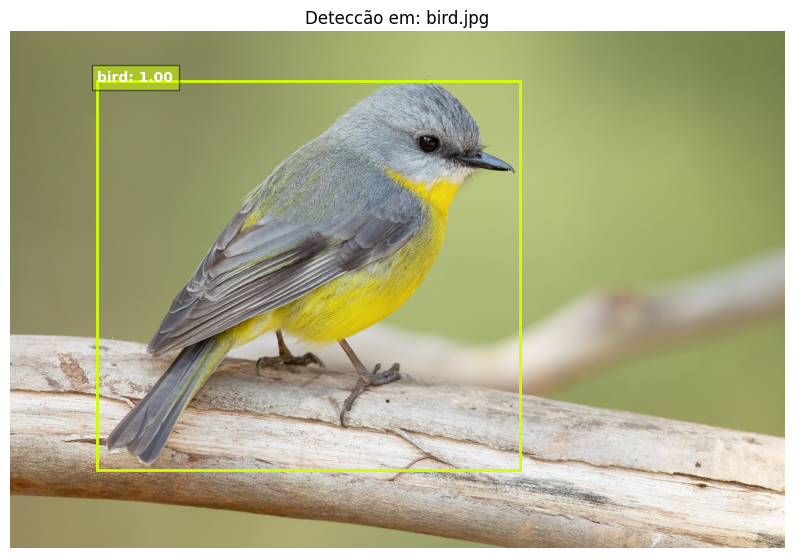


Processando: cats_dog.png...


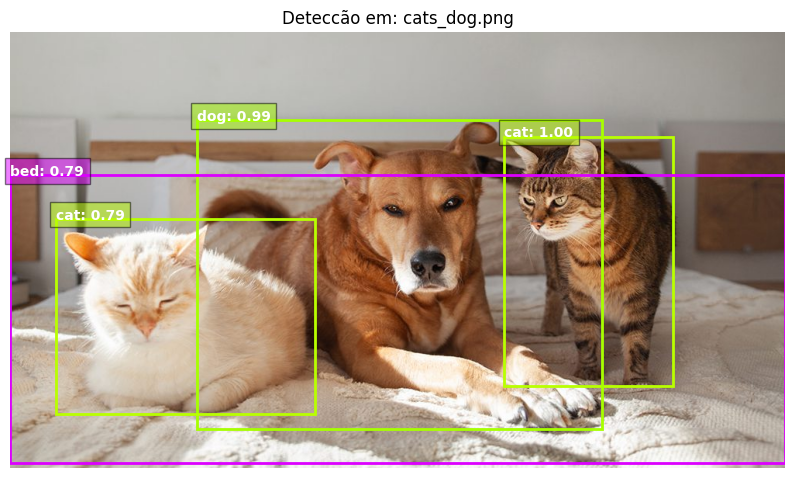


Processando: kitchen.png...


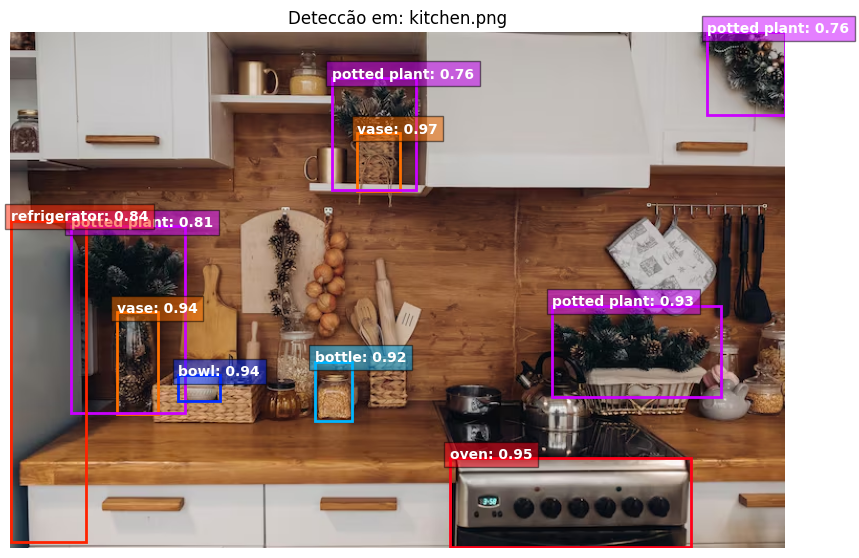


Processando: pizza.png...


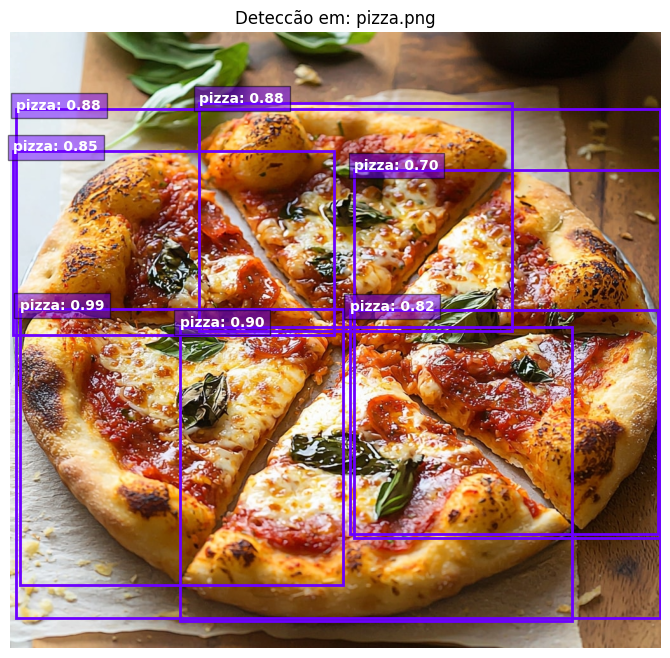

In [3]:
images_dir = "images"
allowed_extensions = (".png", ".jpg", ".jpeg")

for filename in os.listdir(images_dir):
    if filename.lower().endswith(allowed_extensions):
        path = os.path.join(images_dir, filename)
        print(f"\nProcessando: {filename}...")
        # threshold=0.7 para capturar mais objetos se necessário
        detect_objects(path, threshold=0.7)